In [20]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [21]:
class State(TypedDict):
    height: float
    weight: float
    bmi: float
    catagory: str

In [22]:
def bmi(St: State) -> State:

    height = St['height']
    weight = St['weight']
    bmi = weight / (height ** 2)

    St['bmi'] = bmi

    return St


In [23]:
def bmi_catagory(St: State) -> State:

    bmi = St['bmi']
    cat = ''
    if bmi < 18.5:
        cat = 'Under Weight'
    elif bmi >= 18.5 and bmi <25:
        cat = 'Healthy'
    elif bmi >= 25 and bmi < 30:
        cat = 'Overweight'
    elif bmi >= 30 and bmi < 40:
        cat = 'Obesity'
    else:
        cat = 'Severe Obesity'
    
    St['catagory'] = cat

    return St

In [24]:
graph = StateGraph(State)

graph.add_node('BMI', bmi)
graph.add_node('BMI_CAT', bmi_catagory)

graph.add_edge(START, 'BMI')
graph.add_edge('BMI', 'BMI_CAT')
graph.add_edge('BMI_CAT', END)


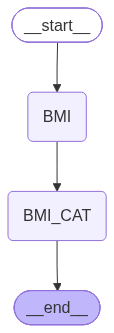

In [25]:
graph.compile()

In [26]:
agent = graph.compile()

In [ ]:
initial_state = {'height': 1.75, 'weight':70}
final_state = agent.invoke(initial_state)

In [28]:
print(final_state)

{'height': 1.75, 'weight': 70, 'bmi': 22.857142857142858, 'catagory': 'Healthy'}


In [29]:
print(round(final_state['bmi'],2))
print(final_state['catagory'])

22.86
Healthy
